# Credit Card Fraud Detection using Machine Learning

## Objective
This project aims to build a machine learning model to detect fraudulent credit card transactions.

## Business Problem
Fraudulent transactions are rare, but they can cause significant financial losses. 
The objective is to identify fraud accurately while minimizing false alarms.

## Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

## Key Focus Areas
- Exploratory data analysis
- Class imbalance handling
- Machine learning model building
- Precision, recall, and F1-score evaluation

In [1]:
# Core libraries for data handling
import pandas as pd
import numpy as np

# Libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Model evaluation metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score
)

## Load Dataset
The dataset contains anonymized transaction features and a target variable indicating fraud status.

In [2]:
# Load the fraud detection dataset
df = pd.read_csv("data/creditcard.csv")

# Display the first 5 rows
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Inspect Dataset
Understand the dataset structure, data types, and missing values before analysis.

In [3]:
# Display the shape of the dataset
print("Dataset shape:", df.shape)

# Display column names and data types
print("\nDataset information:")
print(df.info())

# Check the first few rows
df.head()

Dataset shape: (284807, 31)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
# Check for missing values in each column
print("Missing values:")
print(df.isnull().sum())

Missing values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


## Fraud Class Distribution
Fraud detection datasets are usually highly imbalanced, so we first inspect the target distribution.

In [5]:
# Count the number of legitimate and fraudulent transactions
print(df['Class'].value_counts())

# Calculate the percentage distribution
print(df['Class'].value_counts(normalize=True) * 100)

0    284315
1       492
Name: Class, dtype: int64
0    99.827251
1     0.172749
Name: Class, dtype: float64


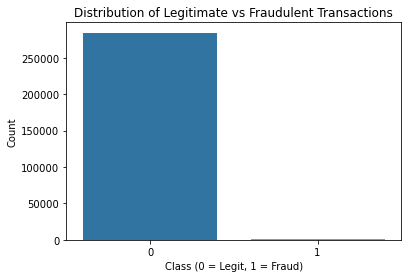

In [6]:
# Visualize the fraud class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df)

plt.title('Distribution of Legitimate vs Fraudulent Transactions')
plt.xlabel('Class (0 = Legit, 1 = Fraud)')
plt.ylabel('Count')

plt.show()

### Interpretation

The dataset is highly imbalanced, with fraudulent transactions representing only a very small proportion of total transactions.

This imbalance is important because accuracy alone would be misleading. 
A model could predict all transactions as legitimate and still achieve a high accuracy score, while failing to detect actual fraud cases.

## Exploratory Data Analysis
Analyze important variables such as transaction amount and transaction time.

In [7]:
# Summary statistics for numerical features
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,3.918649e-15,5.682686e-16,-8.761736e-15,2.811118e-15,-1.552103e-15,2.040130e-15,-1.698953e-15,-1.893285e-16,-3.147640e-15,...,1.473120e-16,8.042109e-16,5.282512e-16,4.456271e-15,1.426896e-15,1.701640e-15,-3.662252e-16,-1.217809e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


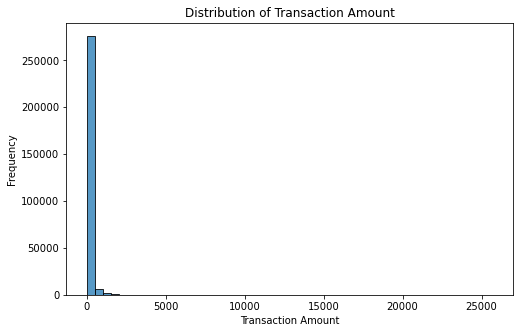

In [8]:
# Plot the distribution of transaction amount
plt.figure(figsize=(8, 5))
sns.histplot(df['Amount'], bins=50)

plt.title('Distribution of Transaction Amount')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')

plt.show()

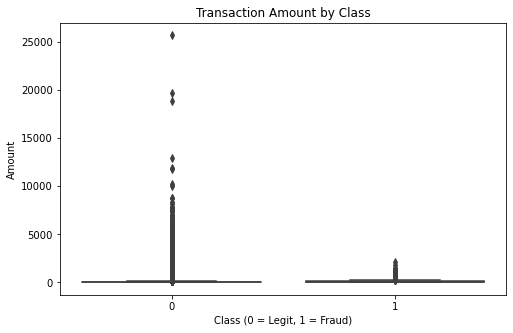

In [9]:
# Compare transaction amount by fraud class
plt.figure(figsize=(8, 5))
sns.boxplot(x='Class', y='Amount', data=df)

plt.title('Transaction Amount by Class')
plt.xlabel('Class (0 = Legit, 1 = Fraud)')
plt.ylabel('Amount')

plt.show()

### Interpretation

The transaction amount distribution is highly skewed, with most transactions being relatively small and a few large outliers.

Comparing transaction amounts across classes can help identify whether fraudulent transactions tend to differ in size from legitimate transactions.

## Feature Scaling
The `Amount` column is scaled to ensure it is on a comparable numerical range for machine learning models.

In [10]:
# Create a copy of the dataset before transformations
data = df.copy()

# Scale the Amount column
scaler = StandardScaler()
data['Scaled_Amount'] = scaler.fit_transform(data[['Amount']])

# Drop the original Amount column after scaling
data = data.drop(columns=['Amount'])

# Preview the transformed dataset
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Class,Scaled_Amount
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.244964
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.342475
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,1.160686
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0.140534
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,-0.073403


## Prepare Features and Target
Separate the input features from the target variable.

In [11]:
# Define feature matrix X and target variable y
X = data.drop('Class', axis=1)
y = data['Class']

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (284807, 30)
Target vector shape: (284807,)


## Train-Test Split
Split the dataset into training and testing sets while preserving the class distribution using stratification.

In [12]:
# Split the data into training and testing sets
# Stratify ensures the fraud ratio remains similar in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (227845, 30)
Testing set shape: (56962, 30)


## Baseline Model: Logistic Regression
Logistic Regression is used as a simple baseline classification model.

In [13]:
# Create and train a logistic regression model
log_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_model.fit(X_train, y_train)

# Generate predictions on the test set
y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]

## Evaluate Baseline Model
Accuracy is not enough for fraud detection, so we focus on precision, recall, F1-score, and ROC-AUC.

In [14]:
# Print classification report for Logistic Regression
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_log))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98     56864
           1       0.04      0.92      0.08        98

    accuracy                           0.96     56962
   macro avg       0.52      0.94      0.53     56962
weighted avg       1.00      0.96      0.98     56962



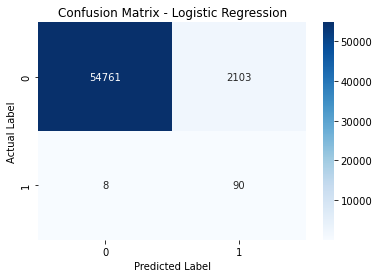

In [15]:
# Display confusion matrix
cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.show()

In [16]:
# Calculate ROC-AUC score
roc_auc_log = roc_auc_score(y_test, y_prob_log)
print("Logistic Regression ROC-AUC Score:", roc_auc_log)

Logistic Regression ROC-AUC Score: 0.9748307454664477


### Interpretation

For fraud detection, recall is especially important because it measures how many actual fraud cases are correctly identified.

Precision is also important because too many false positives may lead to unnecessary transaction blocks or investigations.

The baseline model provides an initial understanding of how well machine learning can distinguish fraudulent transactions from legitimate ones.

## Improved Model: Random Forest
Random Forest is used to capture non-linear relationships and improve fraud detection performance.

In [17]:
# Create and train a Random Forest classifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Generate predictions and predicted probabilities
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [18]:
# Print classification report for Random Forest
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.95      0.73      0.83        98

    accuracy                           1.00     56962
   macro avg       0.97      0.87      0.91     56962
weighted avg       1.00      1.00      1.00     56962



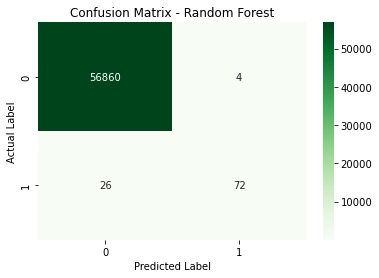

In [19]:
# Display confusion matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')

plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.show()

In [20]:
# Calculate ROC-AUC score for Random Forest
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)
print("Random Forest ROC-AUC Score:", roc_auc_rf)

Random Forest ROC-AUC Score: 0.9478244906572646


## Model Comparison
Compare baseline and improved models using fraud-focused evaluation metrics.

In [21]:
# Create a summary table of key model metrics
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Precision': [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf)
    ],
    'Recall': [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

results

,Model,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.041040,0.918367,0.078568,0.974831
1,Random Forest,0.947368,0.734694,0.827586,0.947824


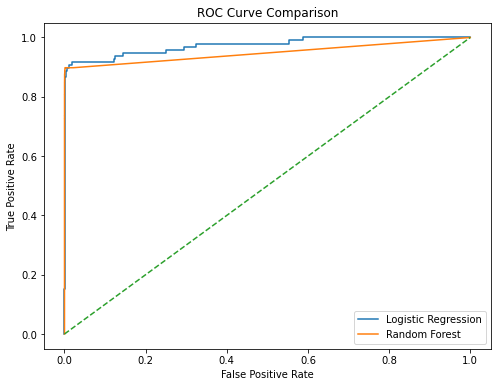

In [22]:
# Plot ROC curves for model comparison
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, label='Logistic Regression')
plt.plot(fpr_rf, tpr_rf, label='Random Forest')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

plt.show()

### Interpretation

The model comparison highlights the trade-off between detecting fraudulent transactions and minimizing false alarms.

Logistic Regression achieved very high recall, meaning it correctly identified most fraudulent transactions. However, its precision was very low, indicating that many legitimate transactions were incorrectly flagged as fraud.

Random Forest achieved much higher precision and F1-score while still maintaining strong recall. This indicates that Random Forest provides a better overall balance between fraud detection and false positive control.

For practical fraud detection systems, balancing recall and precision is important. Detecting fraud is critical, but excessive false positives can disrupt legitimate customer transactions. Based on these results, the Random Forest model provides a more balanced and reliable approach for this dataset.

## Feature Importance
Examine which variables contribute most to fraud detection in the Random Forest model.

In [23]:
# Extract feature importance values from the Random Forest model
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

# Sort features by importance
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

# Display top 10 most important features
feature_importance.head(10)

,Feature,Importance
14,V14,0.179160
10,V10,0.117695
12,V12,0.098331
4,V4,0.093006
17,V17,0.092126
3,V3,0.069427
11,V11,0.056330
16,V16,0.040793
2,V2,0.036311
9,V9,0.026486


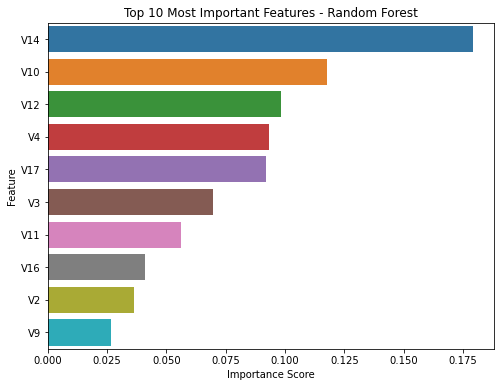

In [24]:
# Plot the top 10 most important features
top_features = feature_importance.head(10)

plt.figure(figsize=(8, 6))
sns.barplot(x='Importance', y='Feature', data=top_features)

plt.title('Top 10 Most Important Features - Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature')

plt.show()

## Key Findings

- The dataset is highly imbalanced, with fraudulent transactions representing only a small fraction of all transactions.
- Accuracy alone is not suitable for this problem because it can hide poor fraud detection performance.
- Logistic Regression provides a strong baseline, especially when class imbalance is handled.
- Random Forest improves detection by capturing more complex patterns in the data.
- Recall and F1-score are more meaningful evaluation metrics than accuracy for this business problem.

## Limitations

- The dataset features are anonymized, which limits interpretability of specific business drivers.
- Fraud detection performance may vary across different transaction environments and time periods.
- The project uses supervised learning and depends on the quality of labeled fraud cases.
- Real-world fraud systems often require additional rules, monitoring, and real-time scoring infrastructure.

## Future Improvements

- Apply advanced models such as XGBoost or LightGBM.
- Use threshold tuning to optimize business trade-offs between false positives and missed fraud.
- Explore resampling methods such as SMOTE for class imbalance handling.
- Build a real-time fraud scoring pipeline for production-style deployment.

## Export Results
Save model comparison results for reporting and future use.

In [25]:
# Save model comparison metrics to CSV
results.to_csv("fraud_model_comparison.csv", index=False)

print("Model comparison file saved successfully.")

Model comparison file saved successfully.
